# Exploratory Data Analysis — Next Day Wildfire Spread

Standalone notebook for Report Section 3.2. **Does not modify `preprocessing.ipynb`** —
it only imports the shared parsing/loading functions from it via `%run`, exactly the way
`cnn_baseline.ipynb` does, so the group's single shared pipeline stays untouched.

Run this after the dataset TFRecords are downloaded into `data/` (same layout the shared
pipeline expects). Everything below reads directly off the **training split only**, since
that mirrors how the shared pipeline itself is allowed to look at the data (val/test stay
untouched until final evaluation).

In [1]:
from pathlib import Path
from IPython import get_ipython
import numpy as np
import matplotlib.pyplot as plt

preprocessing_notebook = Path("shared/preprocessing.ipynb")
if not preprocessing_notebook.exists():
    preprocessing_notebook = Path("../shared/preprocessing.ipynb")
get_ipython().run_line_magic("run", str(preprocessing_notebook))

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DEFAULT_DATA_DIR}")
print(f"Input features ({NUM_CHANNELS}): {INPUT_FEATURES}")

Project root: d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery
Dataset directory: d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery\data
Input features (12): ['elevation', 'th', 'vs', 'tmmn', 'tmmx', 'sph', 'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']


## 1. Load the raw (unnormalized) training split

Using the shared `get_split_files` / `load_split_arrays` so this reads exactly the same files the models train on.

In [2]:
split_files = get_split_files(DEFAULT_DATA_DIR)
print({k: len(v) for k, v in split_files.items()})

train_inputs, train_targets = load_split_arrays(split_files["train"])
val_inputs, val_targets = load_split_arrays(split_files["val"])
test_inputs, test_targets = load_split_arrays(split_files["test"])

print("train:", train_inputs.shape, train_targets.shape)
print("val:  ", val_inputs.shape, val_targets.shape)
print("test: ", test_inputs.shape, test_targets.shape)

{'train': 15, 'val': 2, 'test': 2}
train: (14979, 12, 64, 64) (14979, 1, 64, 64)
val:   (1877, 12, 64, 64) (1877, 1, 64, 64)
test:  (1689, 12, 64, 64) (1689, 1, 64, 64)


## 2. Class balance (fire / no-fire / uncertain pixels)

Computed on the target `FireMask`. The uncertain (`-1`) pixels are excluded from training and evaluation via `valid_mask`; everything else is the real fire/no-fire imbalance that motivates the `pos_weight` strategy in Section 4.

--- train ---
  total pixels:      61,353,984
  fire (1):          658,270  (1.073%)
  no-fire (0):       59,254,803  (96.579%)
  uncertain (-1):    1,440,911  (2.349%)
  fire share of VALID pixels only: 1.099%
  implied pos_weight (neg/pos, valid pixels): 90.02
--- val ---
  total pixels:      7,688,192
  fire (1):          102,594  (1.334%)
  no-fire (0):       7,397,791  (96.223%)
  uncertain (-1):    187,807  (2.443%)
  fire share of VALID pixels only: 1.368%
  implied pos_weight (neg/pos, valid pixels): 72.11
--- test ---
  total pixels:      6,918,144
  fire (1):          84,331  (1.219%)
  no-fire (0):       6,643,368  (96.028%)
  uncertain (-1):    190,445  (2.753%)
  fire share of VALID pixels only: 1.253%
  implied pos_weight (neg/pos, valid pixels): 78.78


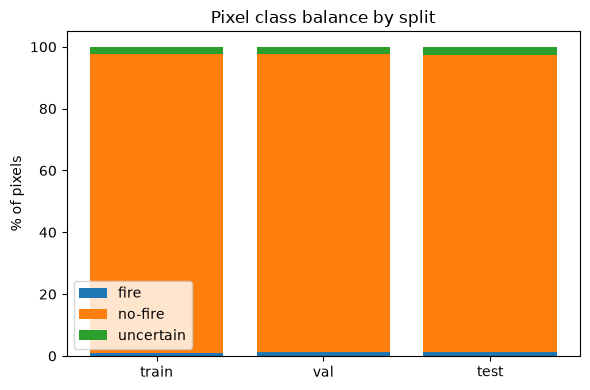

In [3]:
def class_balance(targets, split_name):
    total = targets.size
    n_uncertain = (targets == UNCERTAIN_LABEL_VALUE).sum()
    n_fire = (targets == 1).sum()
    n_nofire = (targets == 0).sum()
    print(f"--- {split_name} ---")
    print(f"  total pixels:      {total:,}")
    print(f"  fire (1):          {n_fire:,}  ({100*n_fire/total:.3f}%)")
    print(f"  no-fire (0):       {n_nofire:,}  ({100*n_nofire/total:.3f}%)")
    print(f"  uncertain (-1):    {n_uncertain:,}  ({100*n_uncertain/total:.3f}%)")
    valid = targets[targets != UNCERTAIN_LABEL_VALUE]
    pos_frac_valid = (valid == 1).mean()
    print(f"  fire share of VALID pixels only: {100*pos_frac_valid:.3f}%")
    print(f"  implied pos_weight (neg/pos, valid pixels): {(1 - pos_frac_valid) / pos_frac_valid:.2f}")
    return {"total": int(total), "fire": int(n_fire), "nofire": int(n_nofire),
            "uncertain": int(n_uncertain), "fire_share_valid": float(pos_frac_valid)}

balance_train = class_balance(train_targets, "train")
balance_val = class_balance(val_targets, "val")
balance_test = class_balance(test_targets, "test")

fig, ax = plt.subplots(figsize=(6, 4))
splits = ["train", "val", "test"]
balances = [balance_train, balance_val, balance_test]
fire_pct = [100 * b["fire"] / b["total"] for b in balances]
nofire_pct = [100 * b["nofire"] / b["total"] for b in balances]
uncertain_pct = [100 * b["uncertain"] / b["total"] for b in balances]
ax.bar(splits, fire_pct, label="fire")
ax.bar(splits, nofire_pct, bottom=fire_pct, label="no-fire")
bottoms = [f + n for f, n in zip(fire_pct, nofire_pct)]
ax.bar(splits, uncertain_pct, bottom=bottoms, label="uncertain")
ax.set_ylabel("% of pixels")
ax.set_title("Pixel class balance by split")
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "eda_class_balance.png"), dpi=150)
plt.show()

## 3. Per-channel distributions (training set)

Summary statistics for each of the 12 input channels, computed ignoring NaNs — this is what justifies the median-imputation and z-score normalization choices in Section 4.

In [4]:
channel_stats = []
for c, name in enumerate(INPUT_FEATURES):
    channel = train_inputs[:, c, :, :]
    pct_nan = 100 * np.isnan(channel).mean()
    stats = {
        "channel": name,
        "mean": float(np.nanmean(channel)),
        "std": float(np.nanstd(channel)),
        "min": float(np.nanmin(channel)),
        "max": float(np.nanmax(channel)),
        "median": float(np.nanmedian(channel)),
        "pct_nan": float(pct_nan),
    }
    channel_stats.append(stats)
    print(f"{name:14s} mean={stats['mean']:>10.3f}  std={stats['std']:>10.3f}  "
          f"min={stats['min']:>10.3f}  max={stats['max']:>10.3f}  NaN={stats['pct_nan']:.2f}%")

import json as _json
with open(str(PROJECT_ROOT / "results" / "eda_channel_stats.json"), "w") as f:
    _json.dump(channel_stats, f, indent=2)

elevation      mean=   896.571  std=   842.610  min=   -45.000  max=  4193.000  NaN=0.00%
th             mean=   146.646  std=  3435.084  min=-505870.062  max= 37735.629  NaN=0.00%
vs             mean=     3.628  std=     1.309  min=   -82.653  max=   103.220  NaN=0.00%
tmmn           mean=   281.852  std=    18.497  min=  -444.693  max=   716.628  NaN=0.00%
tmmx           mean=   297.717  std=    19.458  min=     0.000  max=  1229.849  NaN=0.00%
sph            mean=     0.007  std=     0.004  min=    -0.129  max=     0.086  NaN=0.00%
pr             mean=     0.323  std=     1.534  min=  -167.448  max=    56.215  NaN=0.00%
pdsi           mean=    -0.773  std=     2.441  min=  -125.711  max=    52.269  NaN=0.00%
NDVI           mean=  5350.681  std=  2185.219  min= -9567.000  max=  9966.000  NaN=0.00%
population     mean=    30.460  std=   214.200  min=     0.000  max= 27103.605  NaN=0.00%
erc            mean=    53.469  std=    25.098  min= -1196.089  max=  2470.882  NaN=0.00%
PrevFireM

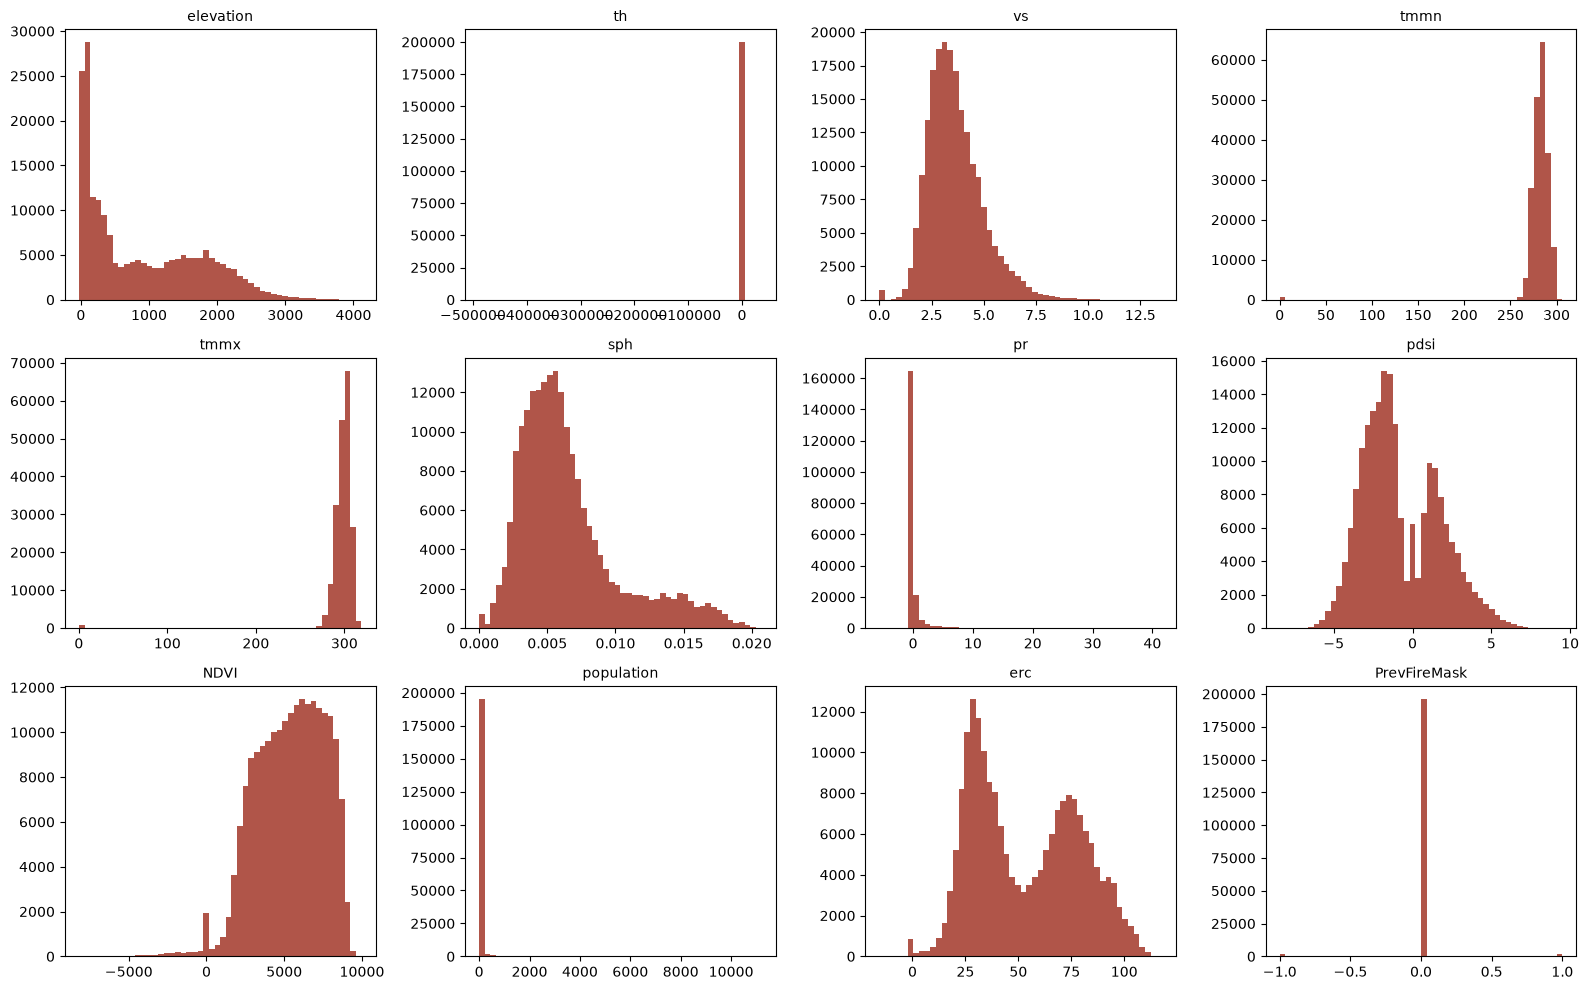

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for c, (name, ax) in enumerate(zip(INPUT_FEATURES, axes.flat)):
    channel = train_inputs[:, c, :, :]
    values = channel[~np.isnan(channel)].ravel()
    sample = values if values.size <= 200_000 else np.random.choice(values, 200_000, replace=False)
    ax.hist(sample, bins=50, color="#9C2B1B", alpha=0.8)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "eda_channel_histograms.png"), dpi=150)
plt.show()

## 3b. Before / after outlier cleaning

The channel stats above were computed on the **raw** training data and showed physically
impossible values in several channels (e.g. `th` outside [0, 360] degrees, negative `vs`/`sph`/`pr`,
`tmmx`/`tmmn` far outside a plausible Kelvin range). The shared pipeline (`preprocessing.ipynb`)
was updated to replace out-of-range values with the training-set median for that channel
(`FEATURE_VALID_RANGES` + `_feature_valid_mask`), the same treatment already used for NaNs.

This section re-runs that cleaning step directly (via the functions `%run` already pulled in
from the shared notebook) and plots before/after histograms + stats, so the fix can be
verified visually rather than just trusted by reading the code.

In [6]:
assert "FEATURE_VALID_RANGES" in dir(), (
    "FEATURE_VALID_RANGES not found — make sure this notebook is using the corrected "
    "preprocessing.ipynb (the one with outlier-range cleaning), not an older version."
)

cleaned_channel_stats = []
for c, name in enumerate(INPUT_FEATURES):
    raw_channel = train_inputs[:, c, :, :]
    valid = _feature_valid_mask(raw_channel, name)
    median = float(np.median(raw_channel[valid])) if valid.any() else float("nan")
    cleaned_channel = np.where(valid, raw_channel, median)

    stats = {
        "channel": name,
        "pct_replaced": float(100 * (~valid).mean()),
        "mean": float(cleaned_channel.mean()),
        "std": float(cleaned_channel.std()),
        "min": float(cleaned_channel.min()),
        "max": float(cleaned_channel.max()),
    }
    cleaned_channel_stats.append(stats)
    print(f"{name:14s} replaced={stats['pct_replaced']:>6.3f}%  "
          f"mean={stats['mean']:>10.3f}  std={stats['std']:>10.3f}  "
          f"min={stats['min']:>10.3f}  max={stats['max']:>10.3f}")

with open(str(PROJECT_ROOT / "results" / "eda_channel_stats_cleaned.json"), "w") as f:
    _json.dump(cleaned_channel_stats, f, indent=2)

elevation      replaced= 0.000%  mean=   896.571  std=   842.610  min=   -45.000  max=  4193.000
th             replaced= 0.229%  mean=   199.420  std=    71.079  min=     0.000  max=   360.000
vs             replaced= 0.000%  mean=     3.628  std=     1.307  min=     0.000  max=    28.517
tmmn           replaced= 0.364%  mean=   282.883  std=     7.205  min=   200.855  max=   329.256
tmmx           replaced= 0.364%  mean=   298.808  std=     7.403  min=   223.607  max=   346.972
sph            replaced= 0.000%  mean=     0.007  std=     0.004  min=     0.000  max=     0.029
pr             replaced= 9.777%  mean=     0.325  std=     1.532  min=     0.000  max=    46.063
pdsi           replaced= 0.001%  mean=    -0.773  std=     2.440  min=    -9.992  max=     9.995
NDVI           replaced= 0.000%  mean=  5350.681  std=  2185.219  min= -9567.000  max=  9966.000
population     replaced= 0.000%  mean=    30.460  std=   214.200  min=     0.000  max= 27103.605
erc            replaced= 0.029

Channels with out-of-range values replaced: ['th', 'vs', 'tmmn', 'tmmx', 'sph', 'pr', 'pdsi', 'erc']


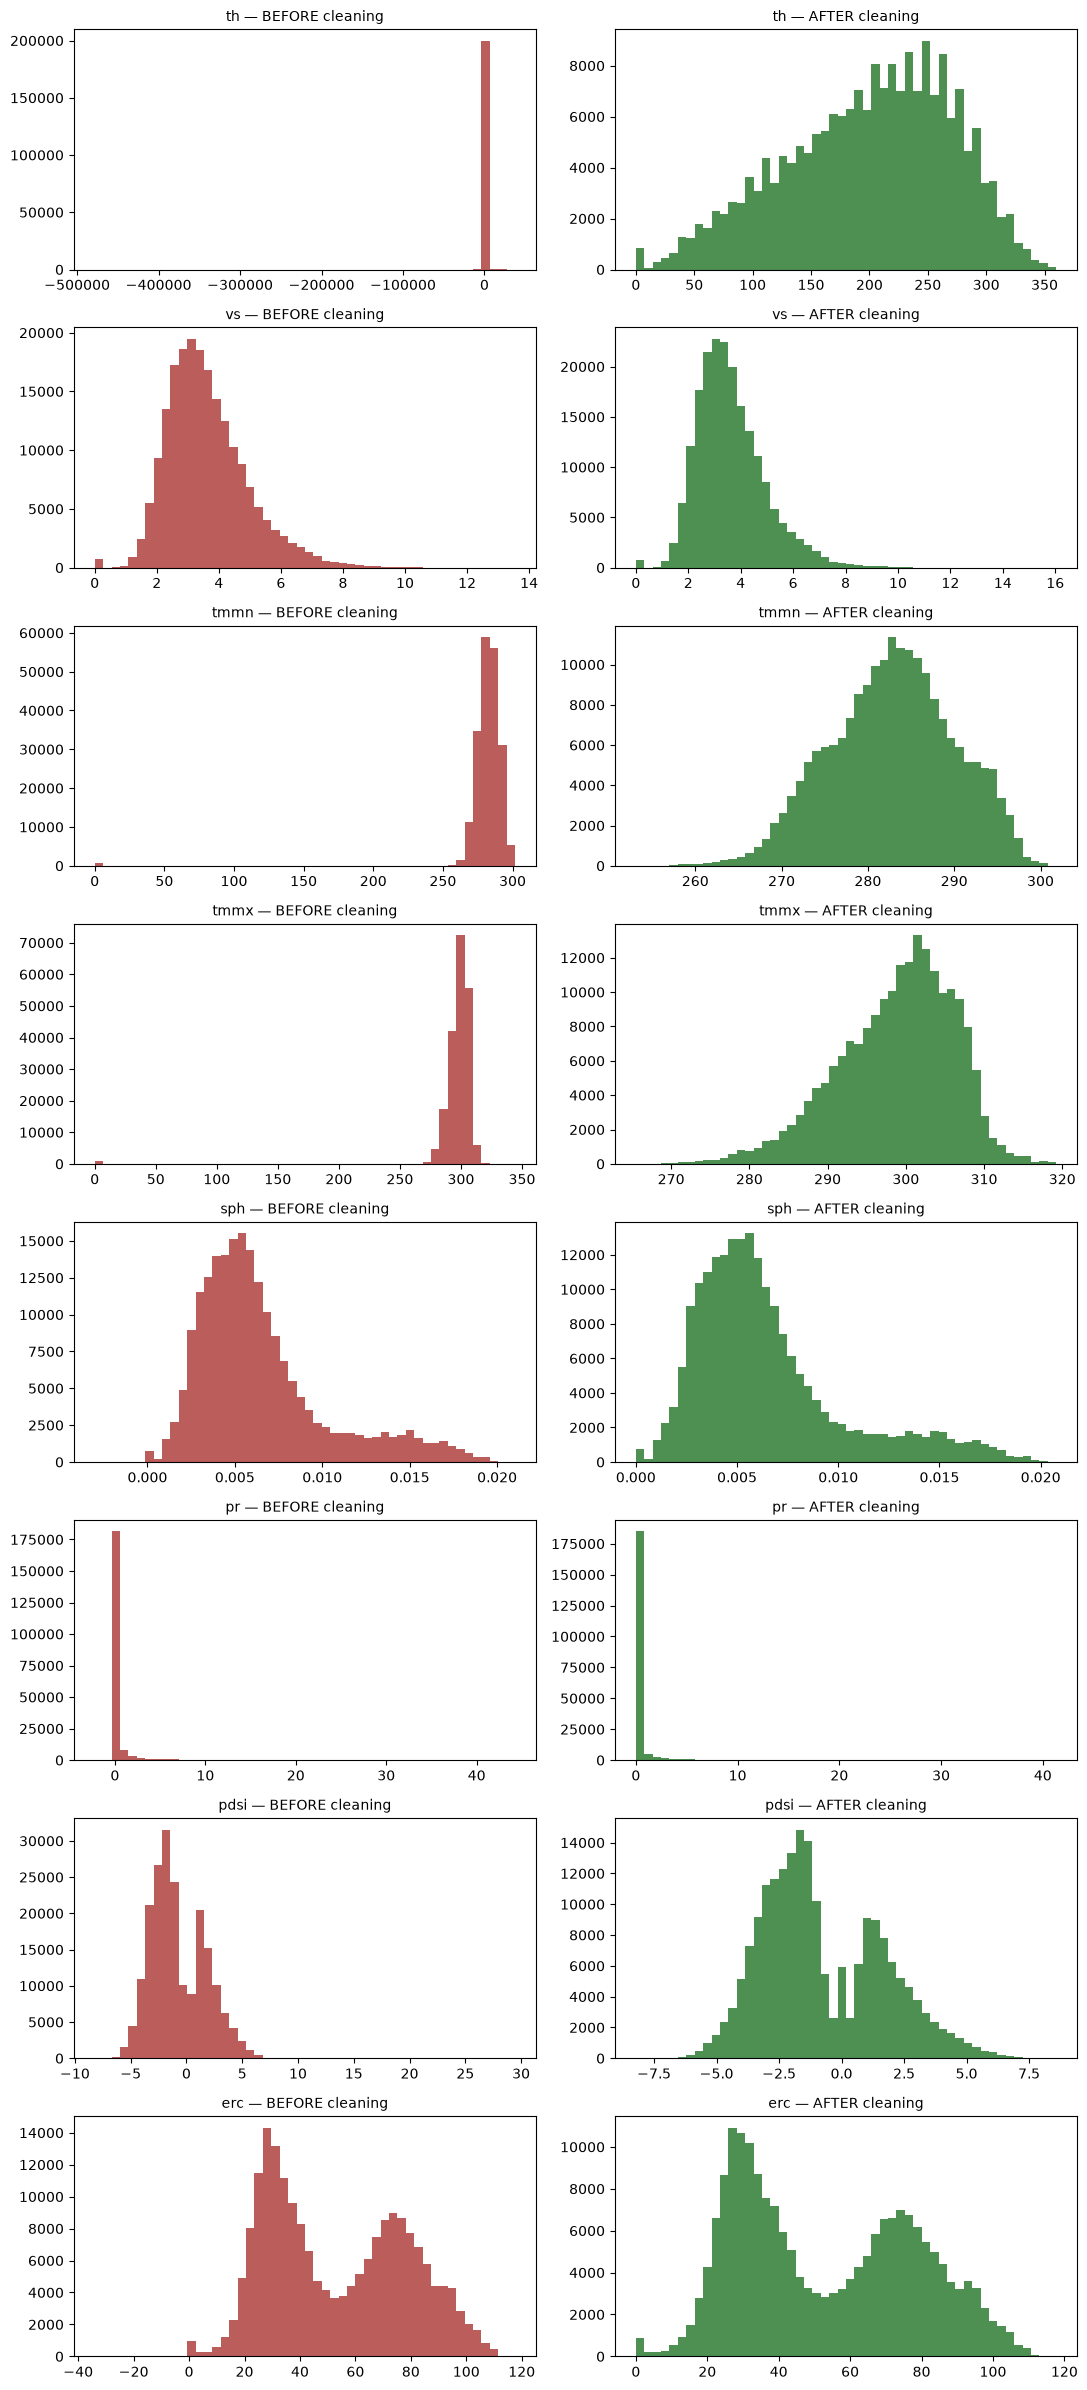

In [7]:
outlier_channels = [s["channel"] for s in cleaned_channel_stats if s["pct_replaced"] > 0]
print(f"Channels with out-of-range values replaced: {outlier_channels}")

n = len(outlier_channels)
fig, axes = plt.subplots(n, 2, figsize=(11, 3 * n))
if n == 1:
    axes = axes[None, :]

for row, name in enumerate(outlier_channels):
    c = INPUT_FEATURES.index(name)
    raw_channel = train_inputs[:, c, :, :]
    valid = _feature_valid_mask(raw_channel, name)
    median = float(np.median(raw_channel[valid])) if valid.any() else float("nan")
    cleaned_channel = np.where(valid, raw_channel, median)

    raw_sample = raw_channel.ravel()
    if raw_sample.size > 200_000:
        raw_sample = np.random.choice(raw_sample, 200_000, replace=False)
    clean_sample = cleaned_channel.ravel()
    if clean_sample.size > 200_000:
        clean_sample = np.random.choice(clean_sample, 200_000, replace=False)

    axes[row, 0].hist(raw_sample, bins=50, color="#B0413E", alpha=0.85)
    axes[row, 0].set_title(f"{name} — BEFORE cleaning", fontsize=10)
    axes[row, 1].hist(clean_sample, bins=50, color="#2E7D32", alpha=0.85)
    axes[row, 1].set_title(f"{name} — AFTER cleaning", fontsize=10)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "eda_outlier_cleaning_before_after.png"), dpi=150)
plt.show()

## 4. Sample patches: PrevFireMask vs. next-day FireMask

Visual sanity check on spatial alignment, plus an intuitive feel for typical fire growth/shrink patterns. Patches are chosen to include at least a few with real fire activity rather than an unbiased random sample (most patches are entirely fire-free).

14979 / 14979 training patches contain at least one fire pixel in PrevFireMask or FireMask.


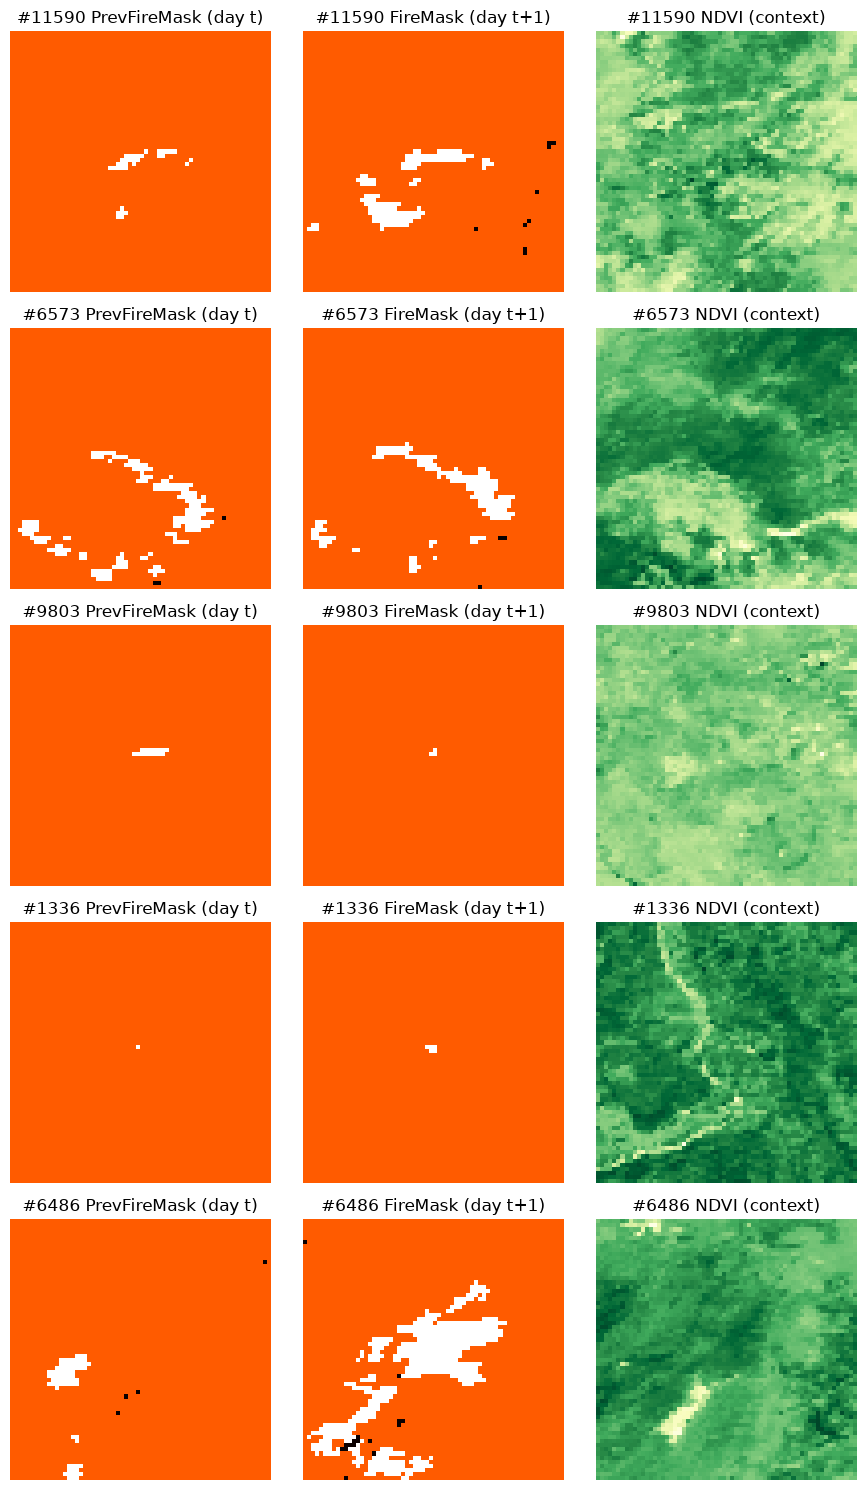

In [8]:
prev_fire_idx = INPUT_FEATURES.index("PrevFireMask")

def has_fire(mask_slice):
    return (mask_slice == 1).sum() > 0

fire_patch_indices = [
    i for i in range(len(train_targets))
    if has_fire(train_targets[i, 0]) or has_fire(train_inputs[i, prev_fire_idx])
]
print(f"{len(fire_patch_indices)} / {len(train_targets)} training patches contain at least one fire pixel "
      f"in PrevFireMask or FireMask.")

rng = np.random.default_rng(SEED)
n_samples = 5
sample_idx = rng.choice(fire_patch_indices, size=min(n_samples, len(fire_patch_indices)), replace=False)

fig, axes = plt.subplots(len(sample_idx), 3, figsize=(9, 3 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = axes[None, :]
for row, idx in enumerate(sample_idx):
    prev_mask = train_inputs[idx, prev_fire_idx]
    next_mask = train_targets[idx, 0]
    ndvi = train_inputs[idx, INPUT_FEATURES.index("NDVI")]

    axes[row, 0].imshow(prev_mask, cmap="hot", vmin=-1, vmax=1)
    axes[row, 0].set_title(f"#{idx} PrevFireMask (day t)")
    axes[row, 1].imshow(next_mask, cmap="hot", vmin=-1, vmax=1)
    axes[row, 1].set_title(f"#{idx} FireMask (day t+1)")
    axes[row, 2].imshow(ndvi, cmap="YlGn")
    axes[row, 2].set_title(f"#{idx} NDVI (context)")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "eda_sample_patches.png"), dpi=150)
plt.show()

## 5. Persistence baseline: PrevFireMask → FireMask overlap

How much of tomorrow's fire mask is already explained by simply repeating today's mask? This gives a naive, non-learned baseline (IoU / F1) that every trained model should meaningfully beat — useful context for Section 7 and Section 8.

In [9]:
def persistence_iou_f1(inputs, targets):
    prev = inputs[:, prev_fire_idx, :, :]
    curr = targets[:, 0, :, :]
    valid = (curr != UNCERTAIN_LABEL_VALUE)

    prev_bin = (prev > 0.5) & valid
    curr_bin = (curr == 1) & valid

    intersection = (prev_bin & curr_bin).sum()
    union = (prev_bin | curr_bin).sum()
    iou = intersection / union if union > 0 else float("nan")

    tp = intersection
    fp = (prev_bin & ~curr_bin).sum()
    fn = (~prev_bin & curr_bin).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")
    return {"iou": float(iou), "precision": float(precision), "recall": float(recall), "f1": float(f1)}

for name, inputs, targets in [("train", train_inputs, train_targets),
                               ("val", val_inputs, val_targets),
                               ("test", test_inputs, test_targets)]:
    metrics = persistence_iou_f1(inputs, targets)
    print(f"{name:6s} persistence baseline -> "
          f"IoU={metrics['iou']:.4f}  F1={metrics['f1']:.4f}  "
          f"precision={metrics['precision']:.4f}  recall={metrics['recall']:.4f}")

train  persistence baseline -> IoU=0.1755  F1=0.2986  precision=0.3462  recall=0.2626
val    persistence baseline -> IoU=0.1220  F1=0.2175  precision=0.2605  recall=0.1866
test   persistence baseline -> IoU=0.1830  F1=0.3093  precision=0.3572  recall=0.2728


## 6. Summary

All figures/JSON above are saved to `results/eda_*`. For **Section 3.2** of the report, paste in:
- `eda_class_balance.png` + the printed class-balance numbers
- `eda_channel_histograms.png` + `eda_channel_stats.json` (raw per-channel summary)
- `eda_outlier_cleaning_before_after.png` + `eda_channel_stats_cleaned.json` — the before/after
  evidence that motivates the range-based cleaning step now in `preprocessing.ipynb` Section 4
  (this pairs well with **Section 4** of the report too, as justification for that design choice)
- `eda_sample_patches.png`
- the persistence-baseline table (train/val/test IoU, F1, precision, recall)